# Mérési notebook
---
# **2. mérési fázis**. A	Modellek tesztelése teljes tanítással.

#### **Cél**: Modellek tesztelése saját adathalmazon, majd saját modell ötletek tesztelése
#### **Diplomamunka címe**: Fotográfiai témafelismerés neurális hálózatokkal nagy adathalmazon.
#### **Készítette**: Sándor Balázs - AZA6NL

## 3. modell **EfficientNet-B0** modell teljes tanítással történő tesztelése

#### A  EfficientNet-B0 modell teljes tanítással történő futtatása a saját SBphotothemes180k adathalmaz Test részhalmazán. (teszt elemszám: 18k).


---


✅ EfficientNet-B0 @ saját 114 kategória modellen

Pontosan ugyanolyan módon, mint a ResNet50 és DenseNet121 esetében:

* utolsó réteg csere

* teljes újratanítás train + val

* részletes statisztikák, grafikon

* .pt mentés

* tesztelés: test halmazon minden metrikával

* Confusion matrix, CSV export, leggyengébb osztályok

✅ 1. Telepítés, import, GPU ellenőrzés

In [ ]:
!pip install -q --upgrade pip
!pip install -q timm torchvision tqdm scikit-learn matplotlib

import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
import numpy as np
import time
import os
from tqdm import tqdm
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("💻 Eszköz:", device)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 81.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 60.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 180.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 195.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 50.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 38.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 154.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 146.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 122.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 108.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 156.6 MB/s eta 0:00:00
💻 Eszköz: cuda


✅ 2. Drive csatolás + adatbázis kibontása

In [ ]:
from google.colab import drive
import zipfile

drive.mount('/content/drive')

diploma_path = "/content/drive/MyDrive/diplomamunka"
zip_path = os.path.join(diploma_path, "imagenet_splitted_db.zip")
extract_path = "/content/imagenet_splitted_db"

if not os.path.exists(extract_path):
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_path)

print("✅ Adatok elérhetők:", extract_path)


Mounted at /content/drive
✅ Adatok elérhetők: /content/imagenet_splitted_db


Mappa pontosítás

In [ ]:
extract_path = "/content/imagenet_splitted_db/imagenet_splitted_db"

✅ 3. Adatok betöltése (train / val / test)

In [ ]:
batch_size = 64
num_workers = 2

transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

train_dataset = datasets.ImageFolder(os.path.join(extract_path, "train"), transform=transform)
val_dataset   = datasets.ImageFolder(os.path.join(extract_path, "val"), transform=transform)
test_dataset  = datasets.ImageFolder(os.path.join(extract_path, "test"), transform=transform)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=num_workers)
val_loader   = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=num_workers)
test_loader  = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=num_workers)

class_names = train_dataset.classes
num_classes = len(class_names)
print(f"📚 Kategóriák száma: {num_classes}")


📚 Kategóriák száma: 114


✅ 4. Modell módosítása (EfficientNet-B0 → 114 osztály)

In [ ]:
model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)
in_features = model.classifier[1].in_features
model.classifier[1] = nn.Linear(in_features, num_classes)
model = model.to(device)


Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth
100%|██████████| 20.5M/20.5M [00:00<00:00, 164MB/s]


✅ 5. Optimizer, loss, statisztikai tárolók

In [ ]:
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
criterion = nn.CrossEntropyLoss()

num_epochs = 10
train_loss_hist, val_loss_hist = [], []
train_acc_hist, val_acc_hist = [], []


✅ 6. Teljes tanítási ciklus (train + val)

In [ ]:
for epoch in range(num_epochs):
    model.train()
    running_loss, correct, total = 0.0, 0, 0

    for inputs, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} - train"):
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()

        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_loss = running_loss / total
    train_acc = correct / total
    train_loss_hist.append(train_loss)
    train_acc_hist.append(train_acc)

    # Validáció
    model.eval()
    val_loss, correct, total = 0.0, 0, 0

    with torch.no_grad():
        for inputs, labels in tqdm(val_loader, desc=f"Epoch {epoch+1}/{num_epochs} - val"):
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            val_loss += loss.item() * inputs.size(0)
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    val_loss /= total
    val_acc = correct / total
    val_loss_hist.append(val_loss)
    val_acc_hist.append(val_acc)

    print(f"📊 Epoch {epoch+1}: Train loss={train_loss:.4f}, acc={train_acc:.4f} | Val loss={val_loss:.4f}, acc={val_acc:.4f}")


Epoch 1/10 - val: 100%|██████████| 282/282 [00:24<00:00, 11.68it/s]


📊 Epoch 1: Train loss=1.7197, acc=0.5629 | Val loss=1.1634, acc=0.6676


Epoch 2/10 - val: 100%|██████████| 282/282 [00:24<00:00, 11.32it/s]


📊 Epoch 2: Train loss=1.0839, acc=0.6881 | Val loss=1.0030, acc=0.7094


Epoch 3/10 - val: 100%|██████████| 282/282 [00:24<00:00, 11.49it/s]


...

📊 Epoch 8: Train loss=0.3823, acc=0.8796 | Val loss=0.9799, acc=0.7661


Epoch 9/10 - val: 100%|██████████| 282/282 [00:24<00:00, 11.45it/s]


📊 Epoch 9: Train loss=0.3299, acc=0.8954 | Val loss=1.0093, acc=0.7684


Epoch 10/10 - val: 100%|██████████| 282/282 [00:24<00:00, 11.31it/s]

📊 Epoch 10: Train loss=0.2928, acc=0.9066 | Val loss=1.0443, acc=0.7658


✅ 7. Tanulási görbék rajzolása

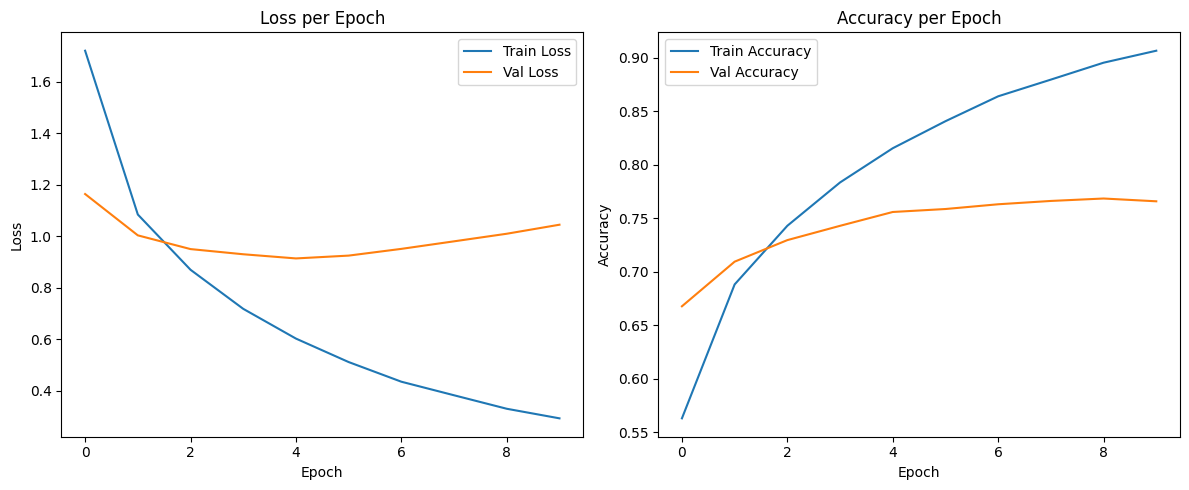

In [ ]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(train_loss_hist, label="Train Loss")
plt.plot(val_loss_hist, label="Val Loss")
plt.title("Loss per Epoch")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_acc_hist, label="Train Accuracy")
plt.plot(val_acc_hist, label="Val Accuracy")
plt.title("Accuracy per Epoch")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.tight_layout()
plt.show()


✅ 8. Modell mentése .pt fájlba

In [ ]:
model_path = "/content/efficientnetb0_finetuned_114.pt"
torch.save(model.state_dict(), model_path)
print(f"💾 Modell mentve: {model_path}")


💾 Modell mentve: /content/efficientnetb0_finetuned_114.pt


✅ 9. Tesztelés a tanított EfficientNet-B0 modellen (test_loader)

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, top_k_accuracy_score

model.eval()
all_preds, all_probs, all_labels = [], [], []

start_time = time.perf_counter()

with torch.no_grad():
    for inputs, labels in tqdm(test_loader, desc="Tesztelés"):
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        probs = F.softmax(outputs, dim=1)
        preds = torch.argmax(probs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

end_time = time.perf_counter()
inference_time = end_time - start_time


Tesztelés: 100%|██████████| 284/284 [00:25<00:00, 11.25it/s]


✅ 10. Metrikák számítása (Top-1, Top-5, Precision, Recall, F1)

In [ ]:
y_true = np.array(all_labels)
y_pred = np.array(all_preds)
y_probs = np.array(all_probs)

accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average='macro', zero_division=0)
recall = recall_score(y_true, y_pred, average='macro', zero_division=0)
f1 = f1_score(y_true, y_pred, average='macro', zero_division=0)
top5 = top_k_accuracy_score(y_true, y_probs, k=5)

print(f"\n🔍 Vizsgálat eredményei (EfficientNet-B0 – Full fine-tune @ saját 114 osztály):")
print(f"✅ Top-1 Accuracy:  {accuracy:.4f}")
print(f"✅ Top-5 Accuracy:  {top5:.4f}")
print(f"🎯 Precision:       {precision:.4f}")
print(f"🎯 Recall:          {recall:.4f}")
print(f"🎯 F1-score:        {f1:.4f}")
print(f"⏱️ Inference time:  {inference_time:.2f} sec")



🔍 Vizsgálat eredményei (EfficientNet-B0 – Full fine-tune @ saját 114 osztály):
✅ Top-1 Accuracy:  0.7649
✅ Top-5 Accuracy:  0.9421
🎯 Precision:       0.7130
🎯 Recall:          0.6950
🎯 F1-score:        0.7001
⏱️ Inference time:  25.26 sec


✅ 11. Confusion Matrix, részletes osztálystatisztika, CSV export

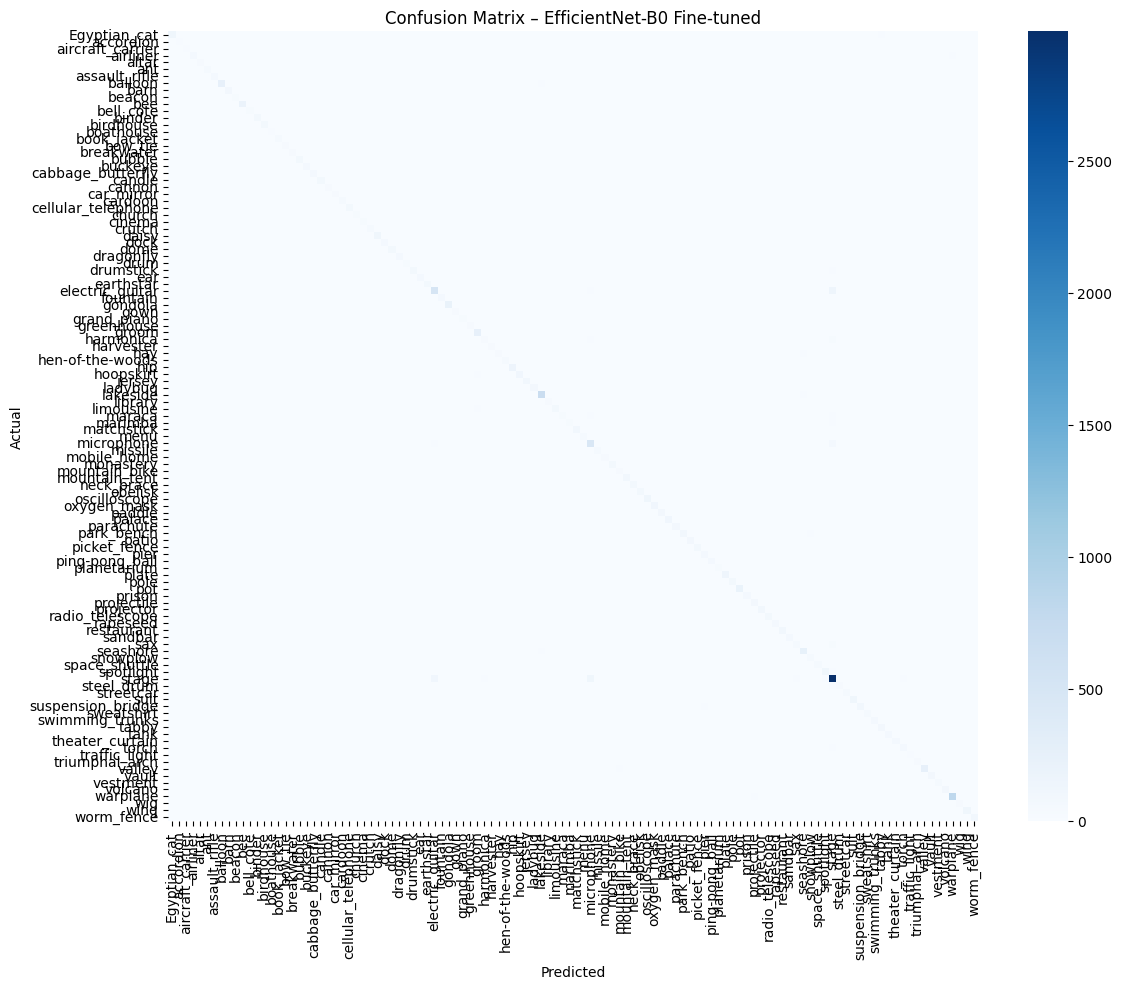


📋 Részletes osztályonkénti metrikák:

                    precision    recall  f1-score   support

      Egyptian_cat       0.88      0.82      0.85       145
         accordion       0.54      0.28      0.37        47
  aircraft_carrier       0.65      0.56      0.60        39
          airliner       0.88      0.74      0.80        80
             altar       0.77      0.73      0.75        59
               ant       0.69      0.58      0.63        95
     assault_rifle       0.83      0.74      0.78        91
           balloon       0.82      0.74      0.78       338
              barn       0.75      0.76      0.75       111
            beacon       0.69      0.44      0.53        62
               bee       0.78      0.86      0.82       212
         bell_cote       0.74      0.45      0.56        77
            binder       0.63      0.73      0.68       105
         birdhouse       0.64      0.61      0.63       116
         boathouse       0.62      0.53      0.57        43


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import pandas as pd
from sklearn.metrics import precision_recall_fscore_support

class_names = test_dataset.classes

# Confusion matrix kirajzolás
conf_mat = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(12, 10))
sns.heatmap(conf_mat, cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix – EfficientNet-B0 Fine-tuned")
plt.tight_layout()
plt.show()

# Osztályonkénti metrikák
print("\n📋 Részletes osztályonkénti metrikák:\n")
print(classification_report(y_true, y_pred, target_names=class_names, zero_division=0))

# CSV export
precision_per_class, recall_per_class, f1_per_class, _ = precision_recall_fscore_support(
    y_true, y_pred, zero_division=0
)

df_metrics = pd.DataFrame({
    "Class": class_names,
    "Precision": precision_per_class,
    "Recall": recall_per_class,
    "F1-score": f1_per_class,
})
df_metrics.to_csv("/content/efficientnetb0_finetune_test_metrics.csv", index=False)
print("📁 Mentve: efficientnetb0_finetune_test_metrics.csv")

# Leggyengébben teljesítő osztályok
print("\n😢 Legrosszabbul teljesítő osztályok:")
print(df_metrics.sort_values("F1-score").head(10))
